# 03 — Exploratory Data Analysis
## Urban Mobility Intelligence Platform | Chicago TNC 2024

### Research Context
This notebook implements **Section III-B: Exploratory Data Analysis** of the paper.

EDA serves three purposes in this research:
1. **Data quality validation** — confirm the stratified sample is clean and consistent
2. **Feature understanding** — identify distributions, outliers, and relationships
   that inform feature engineering decisions in the next stage
3. **Research insights** — surface preliminary findings on surge pricing patterns,
   demand concentration, and spatial disparities across Chicago community areas

### Structure
1. Schema and data type verification
2. Null audit
3. Data consistency checks
4. Column selection
5. Univariate distributions
6. Temporal patterns
7. Zone-level spatial distribution
8. Surge indicator analysis
9. Correlation analysis

### Data Source
BigQuery table: `urban-mobility-intel.chicago_tnc.trips_final`
18,300,000 rows — 366 days x 50,000 stratified random rows per day

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"E:\Projects\ML\Transport-Taxi-Chicago\gcp_credentials.json"

client      = bigquery.Client(project="urban-mobility-intel")
FINAL_TABLE = "urban-mobility-intel.chicago_tnc.trips_final"

# plot styling
plt.rcParams['figure.figsize']  = (12, 5)
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False

print(f"Connected: {client.project}")
print(f"Table: {FINAL_TABLE}")

Connected: urban-mobility-intel
Table: urban-mobility-intel.chicago_tnc.trips_final


## 1. Schema and Data Type Verification
Confirm all columns loaded correctly from BigQuery with expected data types.
This is the first quality gate before any analysis begins.

In [2]:
# schema verification

schema_query = f"""
SELECT
    column_name,
    data_type,
    is_nullable
FROM `urban-mobility-intel.chicago_tnc.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name = 'trips_final'
ORDER BY ordinal_position
"""

schema = client.query(schema_query).to_dataframe()
print("Schema: trips_final")
print(schema.to_string(index=False))

Schema: trips_final
           column_name data_type is_nullable
               trip_id    STRING         YES
  trip_start_timestamp  DATETIME         YES
    trip_end_timestamp  DATETIME         YES
          trip_seconds   FLOAT64         YES
            trip_miles   FLOAT64         YES
 pickup_community_area     INT64         YES
dropoff_community_area     INT64         YES
                  fare   FLOAT64         YES
                   tip   FLOAT64         YES
    additional_charges   FLOAT64         YES
            trip_total   FLOAT64         YES
shared_trip_authorized      BOOL         YES
     shared_trip_match      BOOL         YES
          trips_pooled     INT64         YES


## 2. Null Audit
Identify missing values across all columns.
Null patterns reveal data collection gaps and inform imputation strategy during feature engineering.

In [3]:
# null audit across all columns

null_query = f"""
SELECT
    COUNTIF(trip_id IS NULL)                    AS trip_id,
    COUNTIF(trip_start_timestamp IS NULL)       AS trip_start_timestamp,
    COUNTIF(trip_end_timestamp IS NULL)         AS trip_end_timestamp,
    COUNTIF(trip_seconds IS NULL)               AS trip_seconds,
    COUNTIF(trip_miles IS NULL)                 AS trip_miles,
    COUNTIF(pickup_community_area IS NULL)      AS pickup_community_area,
    COUNTIF(dropoff_community_area IS NULL)     AS dropoff_community_area,
    COUNTIF(fare IS NULL)                       AS fare,
    COUNTIF(tip IS NULL)                        AS tip,
    COUNTIF(additional_charges IS NULL)         AS additional_charges,
    COUNTIF(trip_total IS NULL)                 AS trip_total,
    COUNTIF(shared_trip_authorized IS NULL)     AS shared_trip_authorized,
    COUNTIF(shared_trip_match IS NULL)          AS shared_trip_match,
    COUNTIF(trips_pooled IS NULL)               AS trips_pooled,
    COUNT(*)                                    AS total_rows
FROM `{FINAL_TABLE}`
"""

nulls = client.query(null_query).to_dataframe()

# reshape for readability
null_summary = nulls.T
null_summary.columns = ['count']
null_summary['pct'] = (null_summary['count'] / null_summary.loc['total_rows', 'count'] * 100).round(2)
null_summary = null_summary[null_summary.index != 'total_rows']

print("Null Audit")
print(null_summary.to_string())

Null Audit
                        count   pct
trip_id                     0   0.0
trip_start_timestamp        0   0.0
trip_end_timestamp          0   0.0
trip_seconds              560   0.0
trip_miles                  0   0.0
pickup_community_area       0   0.0
dropoff_community_area      0   0.0
fare                    29093  0.16
tip                     29093  0.16
additional_charges      29093  0.16
trip_total              29093  0.16
shared_trip_authorized      0   0.0
shared_trip_match           0   0.0
trips_pooled                0   0.0


## 3. Data Consistency Checks
Identify impossible or erroneous values:
- Negative fares, miles, or seconds
- Zero distance or zero duration trips
- Trips with no community area assignment
- Fare outliers that suggest data entry errors

These checks inform the data cleaning decisions documented in Section III-C of the paper.

In [4]:
# data consistency checks

consistency_query = f"""
SELECT
    -- negative values
    COUNTIF(trip_seconds < 0)                   AS negative_seconds,
    COUNTIF(trip_miles < 0)                     AS negative_miles,
    COUNTIF(fare < 0)                           AS negative_fare,
    COUNTIF(trip_total < 0)                     AS negative_trip_total,

    -- zero values
    COUNTIF(trip_seconds = 0)                   AS zero_seconds,
    COUNTIF(trip_miles = 0)                     AS zero_miles,
    COUNTIF(fare = 0)                           AS zero_fare,
    COUNTIF(trip_total = 0)                     AS zero_trip_total,

    -- suspicious zone values
    COUNTIF(pickup_community_area = 0)          AS zero_pickup_zone,
    COUNTIF(dropoff_community_area = 0)         AS zero_dropoff_zone,

    -- extreme outliers
    COUNTIF(trip_seconds > 21600)               AS over_6hr_trips,
    COUNTIF(trip_miles > 100)                   AS over_100mile_trips,
    COUNTIF(trip_total > 500)                   AS fare_over_500,

    -- fare vs miles sanity
    COUNTIF(trip_miles > 0 AND trip_total = 0)  AS miles_but_no_fare,
    
    COUNT(*)                                    AS total_rows
FROM `{FINAL_TABLE}`
"""

consistency = client.query(consistency_query).to_dataframe()

result = consistency.T
result.columns = ['count']
result['pct'] = (result['count'] / result.loc['total_rows', 'count'] * 100).round(3)
result = result[result.index != 'total_rows']

print("Consistency Checks")
print(result.to_string())

Consistency Checks
                       count    pct
negative_seconds           0    0.0
negative_miles             0    0.0
negative_fare              0    0.0
negative_trip_total        0    0.0
zero_seconds              38    0.0
zero_miles              1153  0.006
zero_fare              64244  0.351
zero_trip_total        38700  0.211
zero_pickup_zone     1710607  9.348
zero_dropoff_zone    1785217  9.755
over_6hr_trips            32    0.0
over_100mile_trips      4179  0.023
fare_over_500             46    0.0
miles_but_no_fare      38696  0.211


## 4. Column Selection
Evaluate each column for relevance across the three modeling tasks.
Document the final feature set that will be carried into feature engineering.

Modeling tasks:
- Task 1: Surge classification
- Task 2: Fare regression  
- Task 3: Demand forecasting

In [5]:
# column selection — evaluate each column for modeling relevance

# sample 10 rows to inspect actual values
sample_query = f"""
SELECT *
FROM `{FINAL_TABLE}`
LIMIT 10
"""

sample = client.query(sample_query).to_dataframe()
print("Sample rows:")
print(sample.to_string())

# check trips_pooled distribution — is it useful?
pooled_query = f"""
SELECT
    trips_pooled,
    COUNT(*) AS count,
    ROUND(COUNT(*) / 18300000 * 100, 2) AS pct
FROM `{FINAL_TABLE}`
GROUP BY 1
ORDER BY 1
"""

pooled = client.query(pooled_query).to_dataframe()
print("\ntrips_pooled distribution:")
print(pooled.to_string(index=False))

# check shared_trip_match vs shared_trip_authorized
shared_query = f"""
SELECT
    shared_trip_authorized,
    shared_trip_match,
    COUNT(*) AS count
FROM `{FINAL_TABLE}`
GROUP BY 1, 2
ORDER BY 1, 2
"""

shared = client.query(shared_query).to_dataframe()
print("\nShared trip flags:")
print(shared.to_string(index=False))

Sample rows:
                                    trip_id trip_start_timestamp  trip_end_timestamp  trip_seconds  trip_miles  pickup_community_area  dropoff_community_area  fare  tip  additional_charges  trip_total  shared_trip_authorized  shared_trip_match  trips_pooled
0  381554d3d98c24a07804340a7a67f4034455ae97  2024-10-08 02:45:00 2024-10-08 02:45:00         723.0      7.9140                      0                      11   NaN  NaN                 NaN         NaN                   False               True             2
1  5b76baec00b5723a1659762ac0041490fa44d417  2024-10-08 11:15:00 2024-10-08 12:30:00        4208.0     49.2169                      0                       1   NaN  NaN                 NaN         NaN                   False              False             1
2  d4d3ccf72292882979a4dd0145825657faf65d6c  2024-10-08 12:30:00 2024-10-08 13:45:00        4646.0     55.8060                      0                      15   NaN  NaN                 NaN         NaN             

## 5. Univariate Distributions
Analyze the distribution of core numerical variables:
- trip_total (regression target)
- trip_miles
- trip_seconds

Expected: right-skewed distributions (log-normal) for all three.
Log transformation will be applied to trip_total during feature engineering
to normalize the distribution for regression modeling.

Sample pulled: 100,000 rows


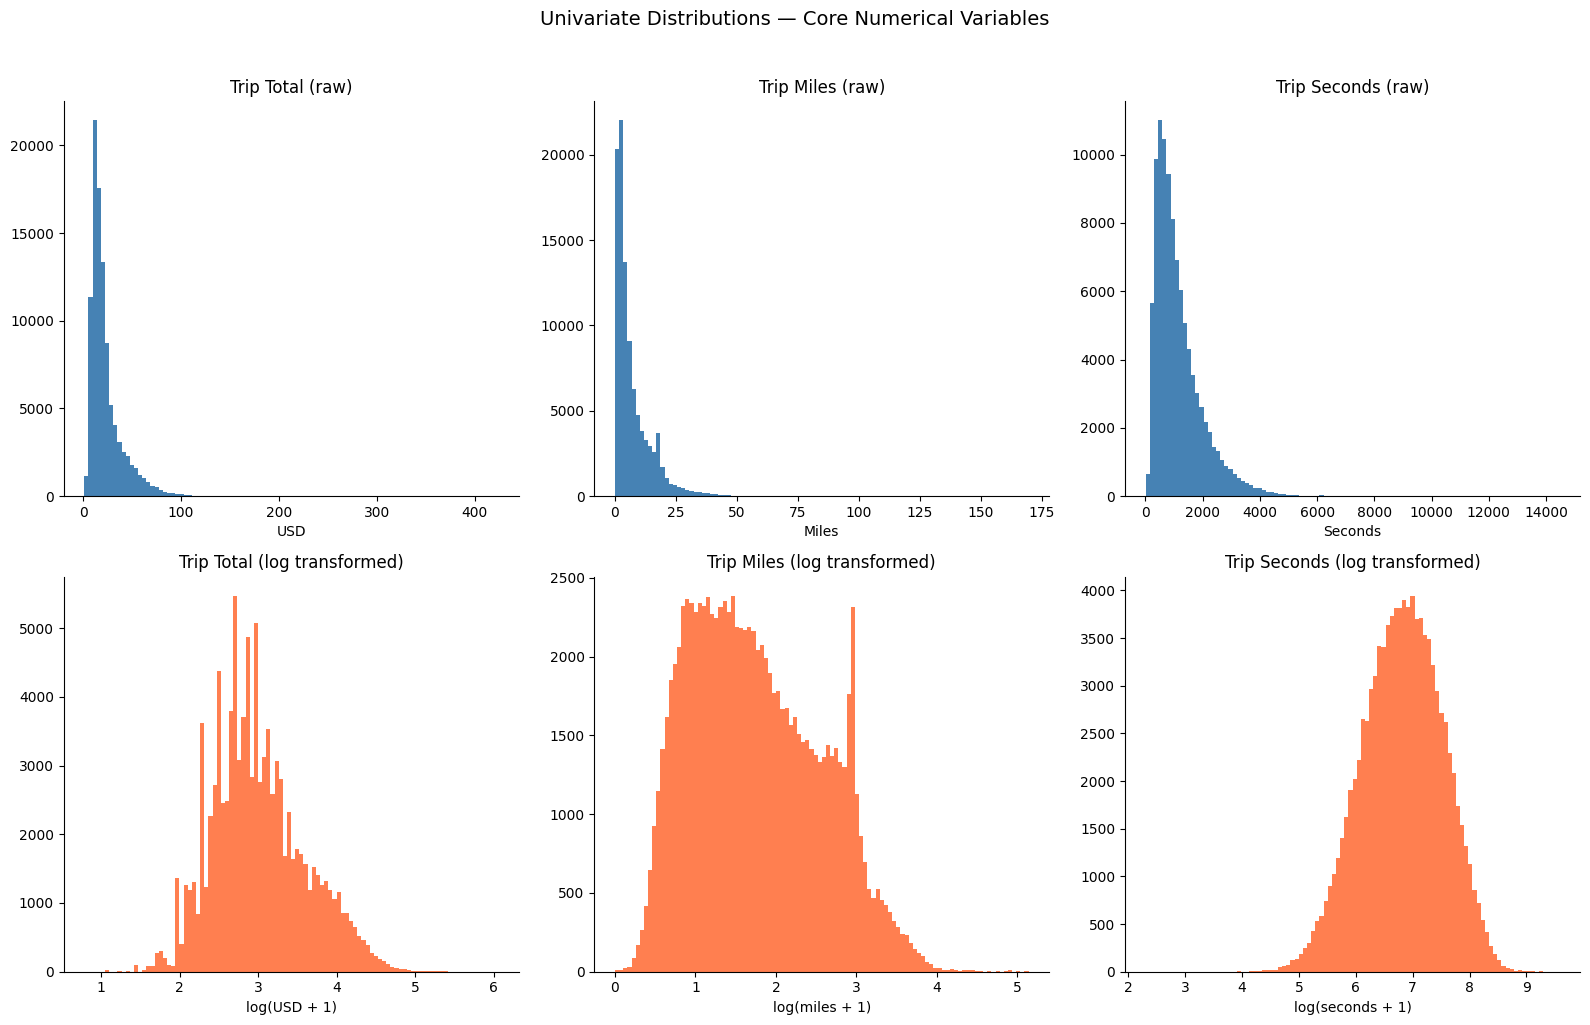


Descriptive Statistics
       trip_total  trip_miles  trip_seconds
count   100000.00   100000.00     100000.00
mean        23.25        7.17       1155.79
std         17.52        7.87        838.46
min          1.19        0.00          9.00
25%         12.32        1.99        559.00
50%         17.81        4.27        927.00
75%         27.78        9.73       1512.00
max        423.46      169.62      14467.00


In [6]:
# pull sample for plotting — 100K rows is sufficient for distribution plots
sample_query = f"""
SELECT
    trip_total,
    trip_miles,
    trip_seconds
FROM `{FINAL_TABLE}`
WHERE trip_total IS NOT NULL
  AND trip_total > 0
  AND trip_miles > 0
  AND trip_seconds > 0
ORDER BY RAND()
LIMIT 100000
"""

df_sample = client.query(sample_query).to_dataframe()
print(f"Sample pulled: {len(df_sample):,} rows")

# plot distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Univariate Distributions — Core Numerical Variables", fontsize=14, y=1.02)

# raw distributions
axes[0, 0].hist(df_sample['trip_total'], bins=100, color='steelblue', edgecolor='none')
axes[0, 0].set_title("Trip Total (raw)")
axes[0, 0].set_xlabel("USD")

axes[0, 1].hist(df_sample['trip_miles'], bins=100, color='steelblue', edgecolor='none')
axes[0, 1].set_title("Trip Miles (raw)")
axes[0, 1].set_xlabel("Miles")

axes[0, 2].hist(df_sample['trip_seconds'], bins=100, color='steelblue', edgecolor='none')
axes[0, 2].set_title("Trip Seconds (raw)")
axes[0, 2].set_xlabel("Seconds")

# log transformed
axes[1, 0].hist(np.log1p(df_sample['trip_total']), bins=100, color='coral', edgecolor='none')
axes[1, 0].set_title("Trip Total (log transformed)")
axes[1, 0].set_xlabel("log(USD + 1)")

axes[1, 1].hist(np.log1p(df_sample['trip_miles']), bins=100, color='coral', edgecolor='none')
axes[1, 1].set_title("Trip Miles (log transformed)")
axes[1, 1].set_xlabel("log(miles + 1)")

axes[1, 2].hist(np.log1p(df_sample['trip_seconds']), bins=100, color='coral', edgecolor='none')
axes[1, 2].set_title("Trip Seconds (log transformed)")
axes[1, 2].set_xlabel("log(seconds + 1)")

plt.tight_layout()
plt.savefig(r"E:\Projects\ML\Transport taxi chicago\data\plots\01_univariate_distributions.png",
            dpi=150, bbox_inches='tight')
plt.show()

# summary statistics
print("\nDescriptive Statistics")
print(df_sample.describe().round(2).to_string())

## 6. Temporal Distribution Analysis
Examine trip patterns across:
- Hour of day — identifies peak demand periods and surge windows
- Day of week — weekday vs weekend behavioral differences  
- Month — seasonal patterns critical for time series forecasting

These temporal patterns directly inform:
- Feature engineering (cyclical encoding of hour and day)
- Time series model seasonality parameters
- Surge classification feature importance expectations

Temporal data pulled: 2,016 rows


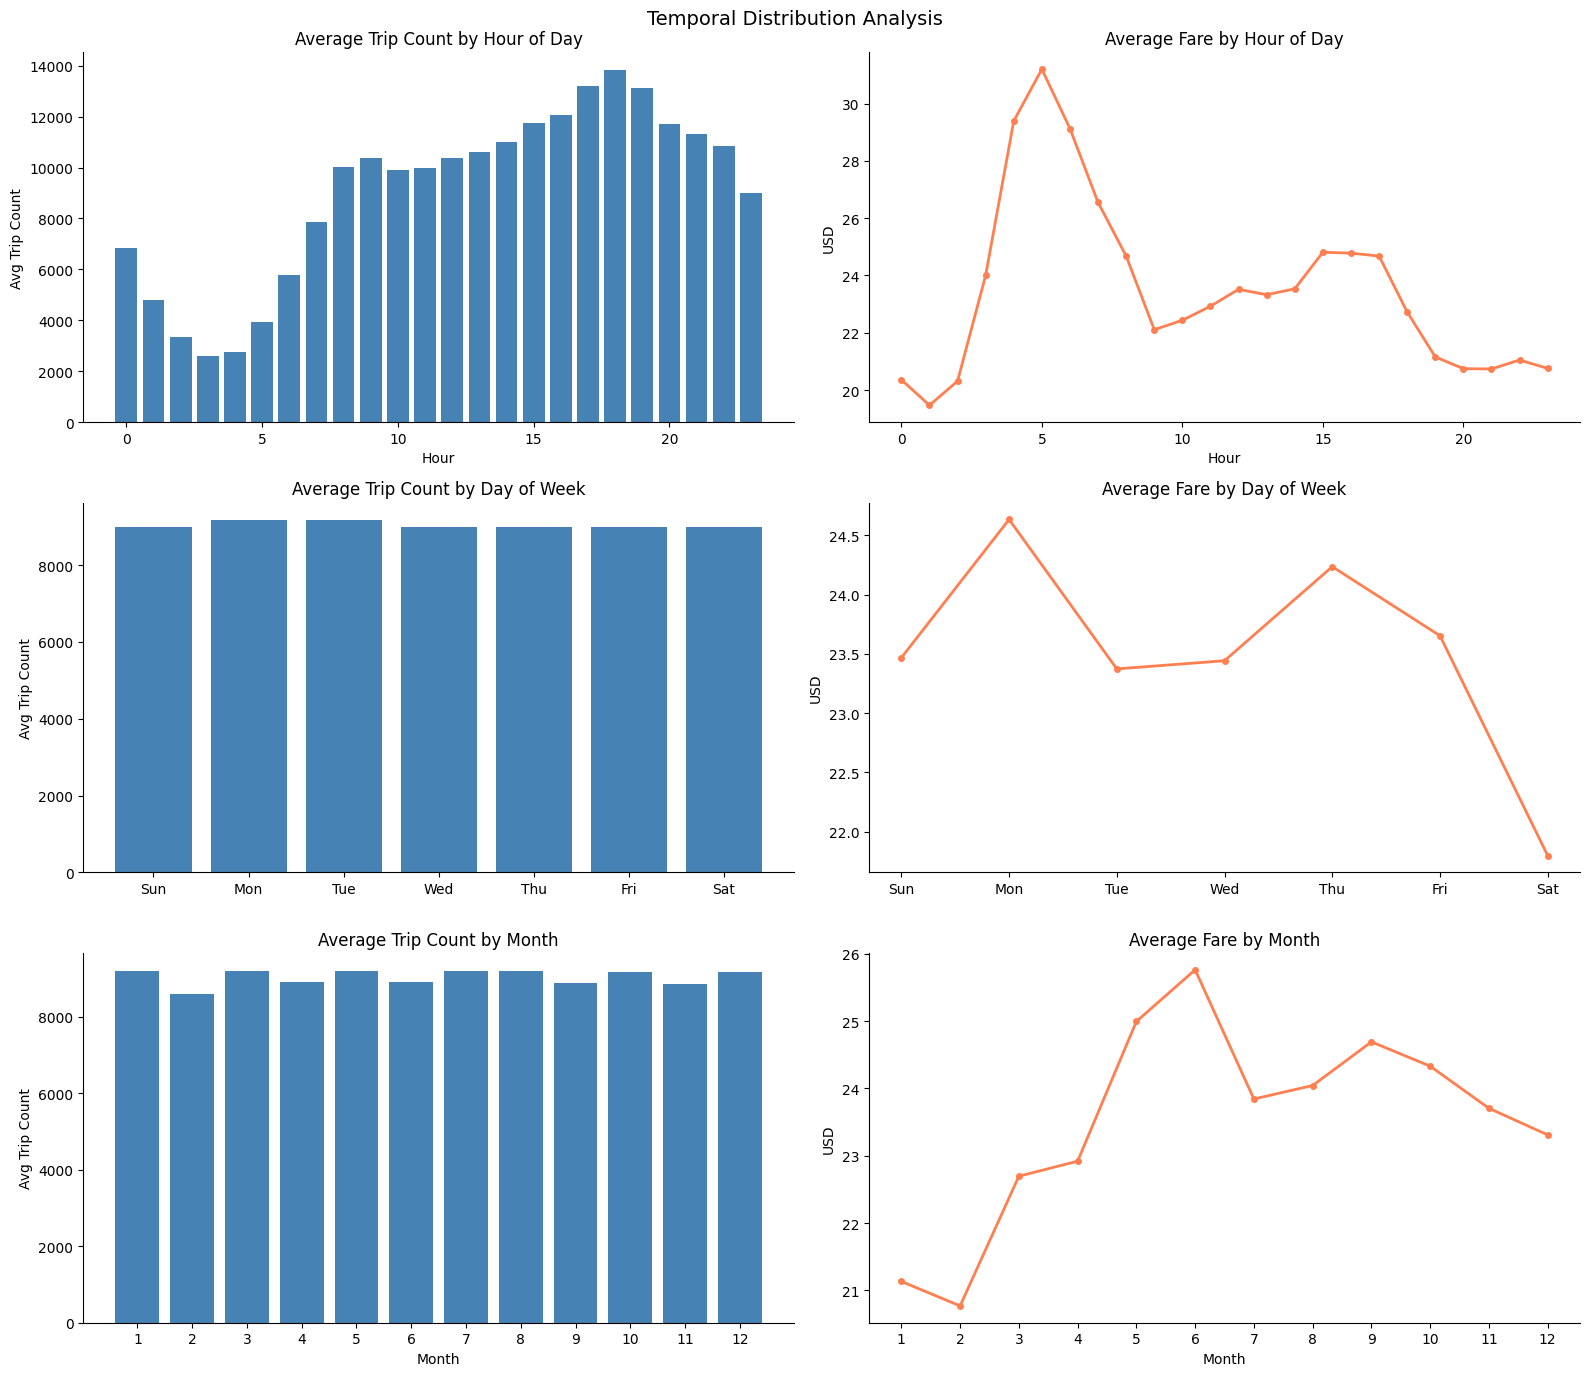

In [7]:
# temporal distribution analysis

temporal_query = f"""
SELECT
    EXTRACT(HOUR FROM trip_start_timestamp)         AS hour_of_day,
    EXTRACT(DAYOFWEEK FROM trip_start_timestamp)    AS day_of_week,
    EXTRACT(MONTH FROM trip_start_timestamp)        AS month,
    COUNT(*)                                        AS trip_count,
    ROUND(AVG(trip_total), 2)                       AS avg_fare,
    ROUND(AVG(trip_miles), 2)                       AS avg_miles
FROM `{FINAL_TABLE}`
WHERE trip_total IS NOT NULL
  AND trip_total > 0
GROUP BY 1, 2, 3
ORDER BY 1, 2, 3
"""

df_temporal = client.query(temporal_query).to_dataframe()
print(f"Temporal data pulled: {len(df_temporal):,} rows")

# aggregate for each plot
hourly  = df_temporal.groupby('hour_of_day')[['trip_count', 'avg_fare']].mean().reset_index()
daily   = df_temporal.groupby('day_of_week')[['trip_count', 'avg_fare']].mean().reset_index()
monthly = df_temporal.groupby('month')[['trip_count', 'avg_fare']].mean().reset_index()

# day labels
day_labels = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle("Temporal Distribution Analysis", fontsize=14)

# hourly trip count
axes[0, 0].bar(hourly['hour_of_day'], hourly['trip_count'], color='steelblue', edgecolor='none')
axes[0, 0].set_title("Average Trip Count by Hour of Day")
axes[0, 0].set_xlabel("Hour")
axes[0, 0].set_ylabel("Avg Trip Count")

# hourly avg fare
axes[0, 1].plot(hourly['hour_of_day'], hourly['avg_fare'], color='coral', linewidth=2, marker='o', markersize=4)
axes[0, 1].set_title("Average Fare by Hour of Day")
axes[0, 1].set_xlabel("Hour")
axes[0, 1].set_ylabel("USD")

# daily trip count
axes[1, 0].bar(daily['day_of_week'], daily['trip_count'], color='steelblue', edgecolor='none')
axes[1, 0].set_xticks(range(1, 8))
axes[1, 0].set_xticklabels(day_labels)
axes[1, 0].set_title("Average Trip Count by Day of Week")
axes[1, 0].set_ylabel("Avg Trip Count")

# daily avg fare
axes[1, 1].plot(day_labels, daily['avg_fare'], color='coral', linewidth=2, marker='o', markersize=4)
axes[1, 1].set_title("Average Fare by Day of Week")
axes[1, 1].set_ylabel("USD")

# monthly trip count
axes[2, 0].bar(monthly['month'], monthly['trip_count'], color='steelblue', edgecolor='none')
axes[2, 0].set_title("Average Trip Count by Month")
axes[2, 0].set_xlabel("Month")
axes[2, 0].set_ylabel("Avg Trip Count")
axes[2, 0].set_xticks(range(1, 13))

# monthly avg fare
axes[2, 1].plot(monthly['month'], monthly['avg_fare'], color='coral', linewidth=2, marker='o', markersize=4)
axes[2, 1].set_title("Average Fare by Month")
axes[2, 1].set_xlabel("Month")
axes[2, 1].set_ylabel("USD")
axes[2, 1].set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig(r"E:\Projects\ML\Transport taxi chicago\data\plots\02_temporal_distribution.png",
            dpi=150, bbox_inches='tight')
plt.show()

## 7. Zone-Level Spatial Distribution
Analyze trip concentration across Chicago's 77 community areas.
Identifies high-demand zones vs underserved areas — 
forms the foundation of the spatial equity analysis in Section V of the paper.

Zones pulled: 77

Top 10 zones by trip count:
 zone  trip_count  avg_fare  avg_miles  avg_seconds  shared_pct
    8     2465858     22.36       5.00       945.69        2.69
   28     1425409     21.20       5.17       964.71        5.00
   32     1373637     24.04       5.53      1021.33        3.39
    6     1013476     20.37       5.05      1009.75        2.76
   76      878872     50.20      18.15      2076.46        0.42
   24      810637     19.34       4.59       910.74        4.00
    7      766766     19.22       4.41       915.45        2.45
   22      498352     18.79       4.83       955.61        4.55
    3      361009     18.78       5.53      1051.37        5.22
   33      352977     25.64       5.93      1127.41        3.99


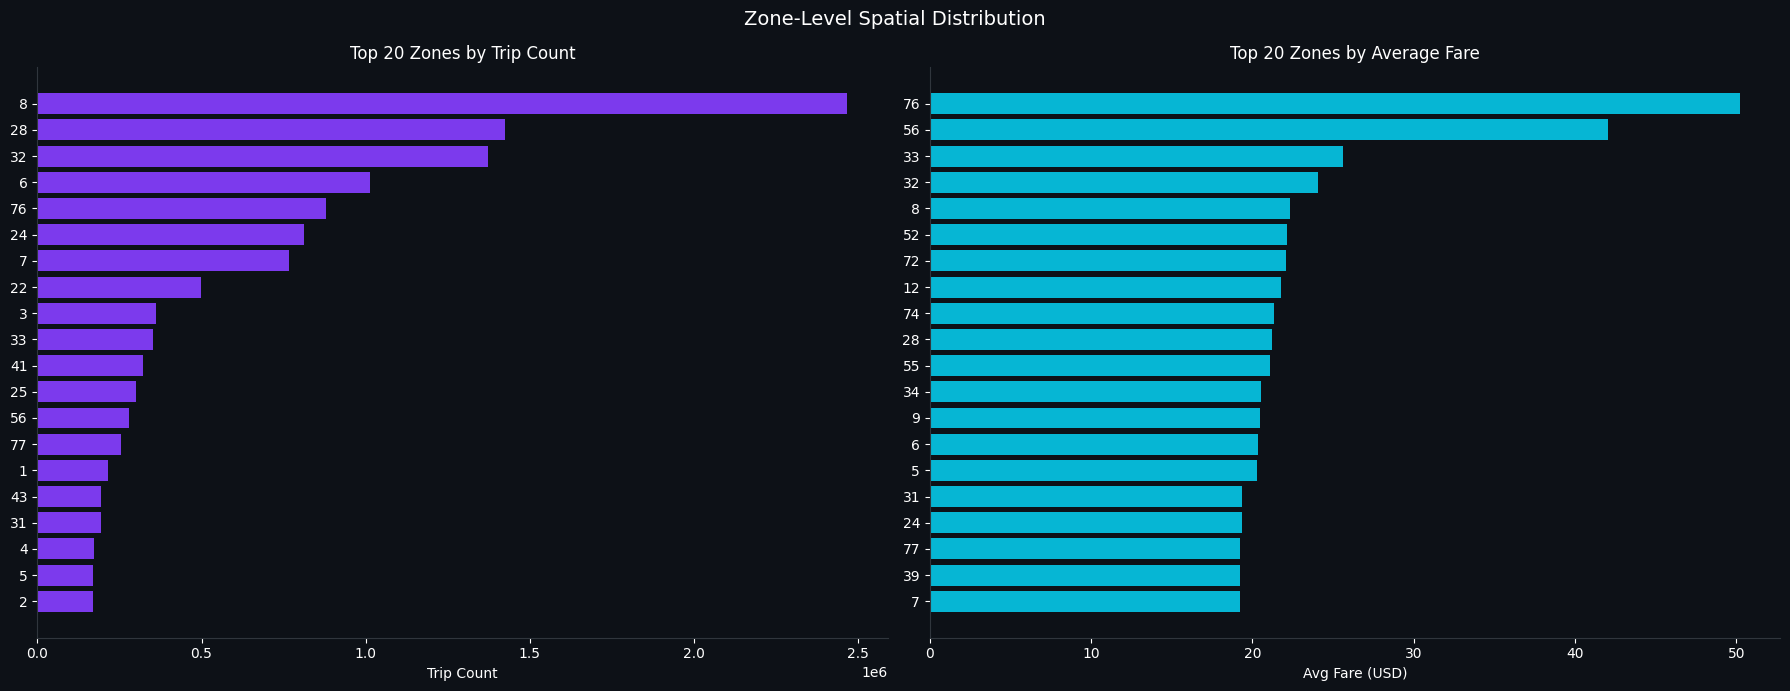

In [8]:
# zone-level spatial distribution

zone_query = f"""
SELECT
    pickup_community_area                       AS zone,
    COUNT(*)                                    AS trip_count,
    ROUND(AVG(trip_total), 2)                   AS avg_fare,
    ROUND(AVG(trip_miles), 2)                   AS avg_miles,
    ROUND(AVG(trip_seconds), 2)                 AS avg_seconds,
    ROUND(COUNTIF(shared_trip_authorized) / COUNT(*) * 100, 2) AS shared_pct
FROM `{FINAL_TABLE}`
WHERE pickup_community_area != 0
  AND trip_total IS NOT NULL
  AND trip_total > 0
GROUP BY 1
ORDER BY 2 DESC
"""

df_zones = client.query(zone_query).to_dataframe()
print(f"Zones pulled: {len(df_zones)}")
print("\nTop 10 zones by trip count:")
print(df_zones.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

# top 20 zones by trip count
top20 = df_zones.head(20)
bars = axes[0].barh(
    top20['zone'].astype(str),
    top20['trip_count'],
    color='#7c3aed'
)
axes[0].invert_yaxis()
axes[0].set_title("Top 20 Zones by Trip Count")
axes[0].set_xlabel("Trip Count")

# avg fare by zone — top 20
top20_fare = df_zones.nlargest(20, 'avg_fare')
axes[1].barh(
    top20_fare['zone'].astype(str),
    top20_fare['avg_fare'],
    color='#06b6d4'
)
axes[1].invert_yaxis()
axes[1].set_title("Top 20 Zones by Average Fare")
axes[1].set_xlabel("Avg Fare (USD)")

plt.suptitle("Zone-Level Spatial Distribution", color='white', fontsize=14)
plt.tight_layout()
plt.savefig(r"E:\Projects\ML\Transport taxi chicago\data\plots\03_zone_distribution.png",
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 8. Surge Indicator Analysis
Define and analyze the surge pricing indicator — the target variable for Task 1.

Surge definition: A trip is classified as surge when the fare-per-mile ratio
exceeds a threshold, indicating elevated pricing relative to distance traveled.

Key questions:
- What percentage of trips are surge? (class balance for classification)
- How does surge rate vary by hour, day, and zone?
- Is the threshold definition defensible for the paper?

In [9]:
# define and analyze surge indicator

# step 1: compute median fare per zone per hour in bigquery
surge_query = f"""
WITH zone_hour_median AS (
    SELECT
        pickup_community_area,
        EXTRACT(HOUR FROM trip_start_timestamp)  AS hour_of_day,
        PERCENTILE_CONT(trip_total, 0.5) OVER (
            PARTITION BY
                pickup_community_area,
                EXTRACT(HOUR FROM trip_start_timestamp)
        )                                        AS median_fare
    FROM `{FINAL_TABLE}`
    WHERE trip_total IS NOT NULL
      AND trip_total > 0
      AND pickup_community_area != 0
),

deduplicated AS (
    SELECT DISTINCT
        pickup_community_area,
        hour_of_day,
        median_fare
    FROM zone_hour_median
),

tagged AS (
    SELECT
        t.trip_total,
        t.pickup_community_area,
        EXTRACT(HOUR FROM t.trip_start_timestamp)   AS hour_of_day,
        EXTRACT(DAYOFWEEK FROM t.trip_start_timestamp) AS day_of_week,
        EXTRACT(MONTH FROM t.trip_start_timestamp)  AS month,
        d.median_fare,
        CASE WHEN t.trip_total > 1.5 * d.median_fare
             THEN 1 ELSE 0 END                      AS is_surge
    FROM `{FINAL_TABLE}` t
    JOIN deduplicated d
        ON  t.pickup_community_area = d.pickup_community_area
        AND EXTRACT(HOUR FROM t.trip_start_timestamp) = d.hour_of_day
    WHERE t.trip_total IS NOT NULL
      AND t.trip_total > 0
      AND t.pickup_community_area != 0
)

SELECT
    -- overall surge rate
    ROUND(AVG(is_surge) * 100, 2)               AS overall_surge_pct,
    COUNTIF(is_surge = 1)                        AS surge_trips,
    COUNTIF(is_surge = 0)                        AS non_surge_trips,
    COUNT(*)                                     AS total_trips
FROM tagged
"""

surge_summary = client.query(surge_query).to_dataframe()
print("Surge Rate Summary")
print(surge_summary.to_string(index=False))

Surge Rate Summary
 overall_surge_pct  surge_trips  non_surge_trips  total_trips
             21.69      3584485         12944005     16528490


## 8.1 Surge Rate by Hour and Zone
Analyze how surge pricing varies across time and space.
These patterns directly inform feature importance expectations
for the LightGBM classifier in Task 1.

Surge temporal data: 12,936 rows


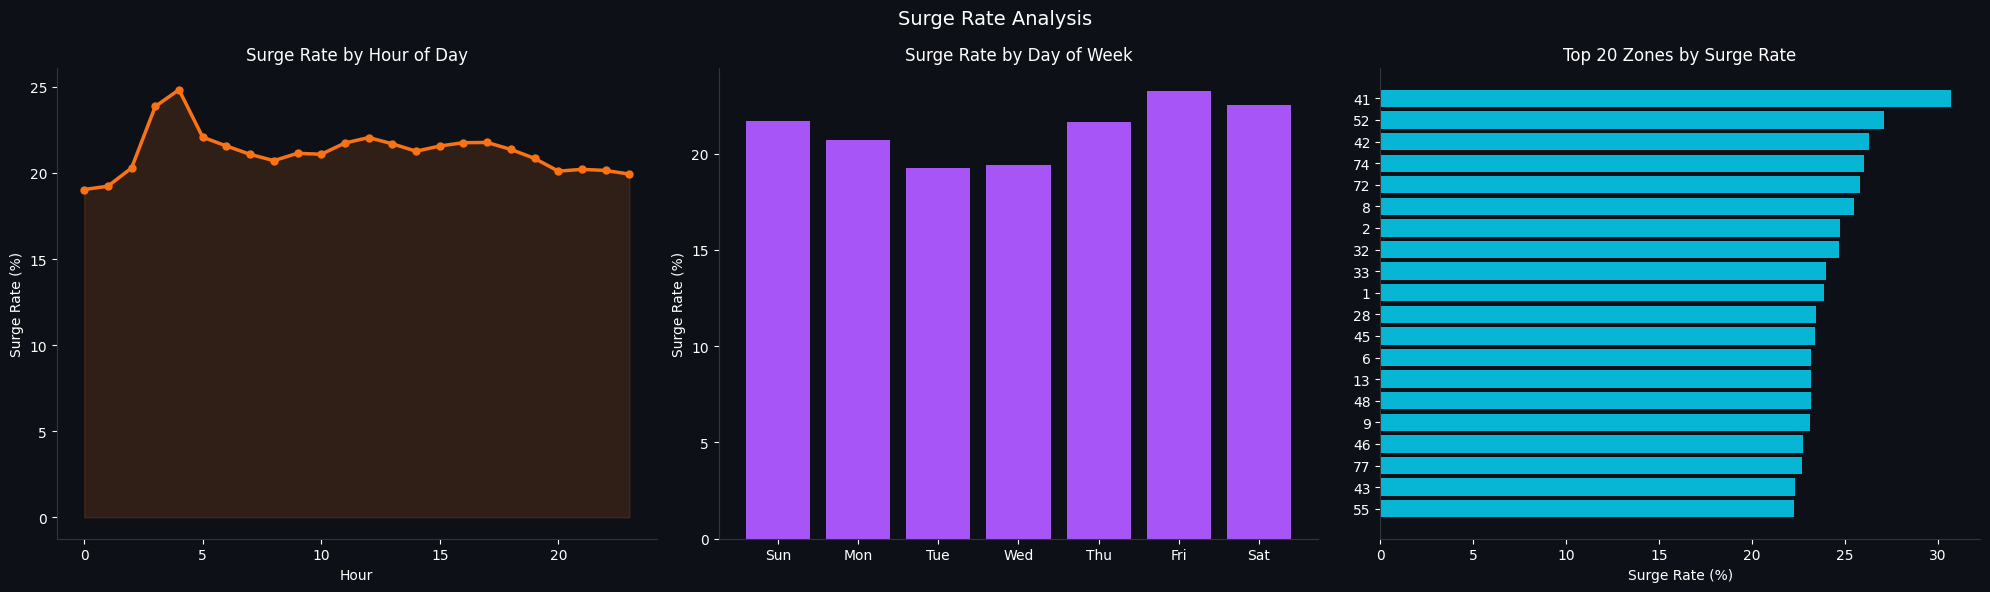

In [10]:
# surge rate by hour and zone
# optimized: pre-aggregate medians first, then join

surge_temporal_query = f"""
WITH medians AS (
    SELECT DISTINCT
        pickup_community_area,
        EXTRACT(HOUR FROM trip_start_timestamp) AS hour_of_day,
        PERCENTILE_CONT(trip_total, 0.5) OVER (
            PARTITION BY
                pickup_community_area,
                EXTRACT(HOUR FROM trip_start_timestamp)
        ) AS median_fare
    FROM `{FINAL_TABLE}`
    WHERE trip_total IS NOT NULL
      AND trip_total > 0
      AND pickup_community_area != 0
),

tagged AS (
    SELECT
        EXTRACT(HOUR FROM t.trip_start_timestamp)      AS hour_of_day,
        EXTRACT(DAYOFWEEK FROM t.trip_start_timestamp) AS day_of_week,
        t.pickup_community_area                        AS zone,
        CASE WHEN t.trip_total > 1.5 * m.median_fare
             THEN 1 ELSE 0 END                         AS is_surge
    FROM `{FINAL_TABLE}` t
    JOIN medians m
        ON  t.pickup_community_area    = m.pickup_community_area
        AND EXTRACT(HOUR FROM t.trip_start_timestamp) = m.hour_of_day
    WHERE t.trip_total IS NOT NULL
      AND t.trip_total > 0
      AND t.pickup_community_area != 0
)

SELECT
    hour_of_day,
    day_of_week,
    zone,
    ROUND(AVG(is_surge) * 100, 2) AS surge_rate,
    COUNT(*)                       AS trip_count
FROM tagged
GROUP BY 1, 2, 3
ORDER BY 1, 2, 3
"""

df_surge = client.query(surge_temporal_query).to_dataframe()
print(f"Surge temporal data: {len(df_surge):,} rows")

# aggregate for plots
hourly_surge  = df_surge.groupby('hour_of_day')['surge_rate'].mean().reset_index()
daily_surge   = df_surge.groupby('day_of_week')['surge_rate'].mean().reset_index()
zone_surge    = df_surge.groupby('zone')['surge_rate'].mean().reset_index().sort_values('surge_rate', ascending=False)

day_labels = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

# surge rate by hour
axes[0].plot(hourly_surge['hour_of_day'], hourly_surge['surge_rate'],
             color='#f97316', linewidth=2.5, marker='o', markersize=5)
axes[0].fill_between(hourly_surge['hour_of_day'], hourly_surge['surge_rate'],
                     alpha=0.15, color='#f97316')
axes[0].set_title("Surge Rate by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Surge Rate (%)")

# surge rate by day of week
axes[1].bar(range(1, 8), daily_surge['surge_rate'],
            color='#a855f7', edgecolor='none')
axes[1].set_xticks(range(1, 8))
axes[1].set_xticklabels(day_labels)
axes[1].set_title("Surge Rate by Day of Week")
axes[1].set_ylabel("Surge Rate (%)")

# top 20 zones by surge rate
top20_surge = zone_surge.head(20)
axes[2].barh(top20_surge['zone'].astype(str), top20_surge['surge_rate'],
             color='#06b6d4', edgecolor='none')
axes[2].invert_yaxis()
axes[2].set_title("Top 20 Zones by Surge Rate")
axes[2].set_xlabel("Surge Rate (%)")

plt.suptitle("Surge Rate Analysis", color='white', fontsize=14)
plt.tight_layout()
plt.savefig(r"E:\Projects\ML\Transport taxi chicago\data\plots\04_surge_analysis.png",
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 9. Correlation Analysis
Examine relationships between numerical variables to:
- Identify multicollinearity before feature engineering
- Confirm expected relationships (miles vs fare, seconds vs fare)
- Identify which variables are redundant and can be dropped

High correlation between trip_seconds and trip_miles is expected —
both measure trip length from different dimensions.
PCA or feature selection will handle multicollinearity during modeling.

Sample pulled: 200,000 rows


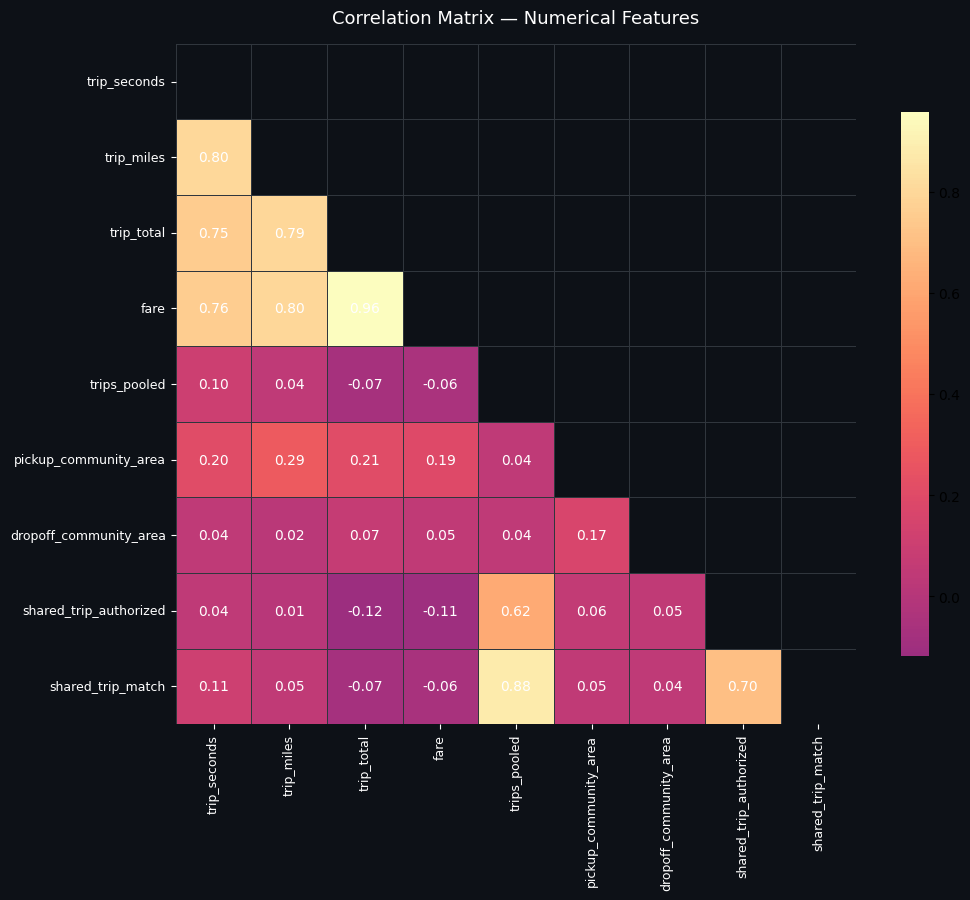


Key Correlations with trip_total:
trip_total                1.000000
fare                      0.957627
trip_miles                0.793694
trip_seconds              0.747936
pickup_community_area     0.208692
dropoff_community_area    0.070140
trips_pooled             -0.065966
shared_trip_match        -0.072778
shared_trip_authorized   -0.118315


In [11]:
# correlation analysis
# pull sample for correlation — 200K rows sufficient

corr_query = f"""
SELECT
    trip_seconds,
    trip_miles,
    trip_total,
    fare,
    trips_pooled,
    pickup_community_area,
    dropoff_community_area,
    CAST(shared_trip_authorized AS INT64) AS shared_trip_authorized,
    CAST(shared_trip_match AS INT64)      AS shared_trip_match
FROM `{FINAL_TABLE}`
WHERE trip_total IS NOT NULL
  AND trip_total > 0
  AND trip_miles > 0
  AND trip_seconds > 0
  AND pickup_community_area != 0
ORDER BY RAND()
LIMIT 200000
"""

df_corr = client.query(corr_query).to_dataframe()
print(f"Sample pulled: {len(df_corr):,} rows")

# compute correlation matrix
corr_matrix = df_corr.corr()

# plot
fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='magma',
    center=0,
    square=True,
    linewidths=0.5,
    linecolor='#30363d',
    annot_kws={'size': 10, 'color': 'white'},
    ax=ax,
    cbar_kws={'shrink': 0.8}
)

ax.set_title("Correlation Matrix — Numerical Features", color='white', fontsize=13, pad=15)
ax.tick_params(colors='white', labelsize=9)
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')

plt.tight_layout()
plt.savefig(r"E:\Projects\ML\Transport taxi chicago\data\plots\05_correlation_matrix.png",
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# print key correlations
print("\nKey Correlations with trip_total:")
print(corr_matrix['trip_total'].sort_values(ascending=False).to_string())

## 10. EDA Summary & Data Cleaning Decisions
Consolidate all findings from the exploratory analysis into a single reference.
This section maps directly to Section III-C of the paper: Data Preprocessing.

### Key Findings
1. **Dataset:** 18.3M rows, 366 days, 78 zones, full 2024 coverage
2. **Nulls:** 29,093 rows with missing financial data (0.16%), 560 missing duration (0.003%)
3. **Out-of-city trips:** 1.8M rows (9.75%) with zero zone — retained with `is_out_of_city` flag
4. **Distributions:** All numerical variables right-skewed — log transformation required
5. **Bimodal distance:** Two distinct trip populations — urban and airport/suburban
6. **Surge rate:** 21.69% — manageable class imbalance, scale_pos_weight = 3.61
7. **Spatial equity:** High surge rates in low-income south/west zones (41, 52, 42)
8. **Multicollinearity:** fare dropped (r=0.96 with trip_total), trip_seconds and trip_miles retained

### Cleaning Decisions
| Issue | Action | Rows affected |
|---|---|---|
| Null financial columns | Drop | 29,093 |
| Null trip_seconds | Drop | 560 |
| Zero trip_seconds or trip_miles | Drop | ~1,191 |
| Zero fare with valid miles | Drop | ~38,696 |
| fare column | Drop — leakage risk | all rows |
| Zero pickup/dropoff zone | Flag as is_out_of_city=1, retain | ~1.8M |

### Variables Carried into Feature Engineering
trip_start_timestamp, trip_end_timestamp, trip_seconds, trip_miles,
pickup_community_area, dropoff_community_area, trip_total,
shared_trip_authorized, shared_trip_match, trips_pooled, is_out_of_city

In [12]:
# eda summary statistics — final reference before feature engineering

summary_query = f"""
SELECT
    COUNT(*)                                            AS total_rows,
    COUNT(DISTINCT DATE(trip_start_timestamp))          AS distinct_days,
    COUNT(DISTINCT pickup_community_area)               AS distinct_zones,
    ROUND(AVG(trip_total), 2)                           AS avg_fare,
    ROUND(AVG(trip_miles), 2)                           AS avg_miles,
    ROUND(AVG(trip_seconds), 2)                         AS avg_seconds,
    COUNTIF(trip_total IS NULL)                         AS null_fares,
    COUNTIF(trip_seconds IS NULL)                       AS null_seconds,
    COUNTIF(pickup_community_area = 0)                  AS out_of_city,
    COUNTIF(trip_miles = 0)                             AS zero_miles,
    COUNTIF(trip_seconds = 0)                           AS zero_seconds,
    COUNTIF(trip_total = 0)                             AS zero_fares
FROM `{FINAL_TABLE}`
"""

summary = client.query(summary_query).to_dataframe()
print("EDA Final Summary")
print(summary.T.to_string())

print("\nCleaning decisions:")
print("  - Rows to drop (nulls + zeros + zero fare with miles): ~69,500")
print("  - Rows to flag (out of city):                          ~1,800,000")
print("  - Rows to flag (fare column):                          retain, drop only at modeling stage")
print("  - Final analytical dataset estimate:                   ~18,230,000 rows")
print("\nEDA complete. Proceed to 04_feature_engineering.ipynb")

EDA Final Summary
                       0
total_rows      18300000
distinct_days        366
distinct_zones        78
avg_fare           23.17
avg_miles           7.18
avg_seconds      1156.75
null_fares         29093
null_seconds         560
out_of_city      1710607
zero_miles          1153
zero_seconds          38
zero_fares         38700

Cleaning decisions:
  - Rows to drop (nulls + zeros + zero fare with miles): ~69,500
  - Rows to flag (out of city):                          ~1,800,000
  - Rows to flag (fare column):                          retain, drop only at modeling stage
  - Final analytical dataset estimate:                   ~18,230,000 rows

EDA complete. Proceed to 04_feature_engineering.ipynb
